In [1]:
##datos sintentico
#Libreria SDv
#FECHA: 05/06/2026
#Autor: Manuel Mendoza Pimentel


In [2]:
import pandas as pd
import numpy as np
import random

In [3]:
import sdv
import sdmetrics

In [4]:
# importamos sublibrerias para la generacion de datos
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [5]:
#Importams sublibrerias para la evaluacion de datos
from sdmetrics.reports.single_table import QualityReport

In [6]:
print("SDV: ", sdv.__version__)
print("SDMetrics:", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics: 0.28.0


In [7]:
#Creamos una tabla de datos reakes como base para la generacion de datos sinteticos
dfClientes = pd.DataFrame(
    {
        "cliente_id": [1,2,3,4,5,6,7,8,9,10],
        "edad": [17,18,19,25,32,42,70,28,23,22],
        "igreso_mensual": [1800,2000,2500,5000,18000,35000,7000, 150000, 4000, 5000],
        "ciudad": ["Cordoba", "Cuitlahuac", "Orizaba", "Yanga", "CDMX", "Tonala", "Ciudad Juarez", "Tierra Blanca", "Nuevo Leon", "Toluca"] 
    }
)

In [8]:
dfClientes

,cliente_id,edad,igreso_mensual,ciudad
0,1,17,1800,Cordoba
1,2,18,2000,Cuitlahuac
2,3,19,2500,Orizaba
3,4,25,5000,Yanga
4,5,32,18000,CDMX
5,6,42,35000,Tonala
6,7,70,7000,Ciudad Juarez
7,8,28,150000,Tierra Blanca
8,9,23,4000,Nuevo Leon
9,10,22,5000,Toluca


In [9]:
#Creamos una instancia de SingleTableMetadata

In [10]:
metadata = SingleTableMetadata()

In [11]:
metadata.detect_from_dataframe(
    data= dfClientes
)

In [12]:
metadata.to_dict

<bound method SingleTableMetadata.to_dict of {
    "columns": {
        "cliente_id": {
            "sdtype": "id"
        },
        "edad": {
            "sdtype": "numerical"
        },
        "igreso_mensual": {
            "sdtype": "numerical"
        },
        "ciudad": {
            "sdtype": "categorical"
        }
    },
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "primary_key": "cliente_id"
}>

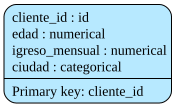

In [13]:
metadata.visualize()

In [14]:
## Entrenar el modelo de datos sinteticos 
#un sinthetisizer es el encargado de geerar los datos sinteticos

In [15]:
#pasar lo metadatos
sintetizador = GaussianCopulaSynthesizer(
    metadata
)

D:\anaconda\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

D:\anaconda\Lib\site-packages\sdv\single_table\base.py:138: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [16]:
#Entrenamos con datos reales
sintetizador.fit(
    dfClientes
)


In [18]:
dfClientes_sinteticos = sintetizador.sample(
    num_rows = 200
)

In [19]:
dfClientes_sinteticos

,cliente_id,edad,igreso_mensual,ciudad
0,16169768,45,37039,Orizaba
1,4918803,18,2000,Cuitlahuac
2,1900081,20,2000,Cordoba
3,531516,18,2000,Cordoba
4,10211768,32,2517,CDMX
...,...,...,...,...
195,1577423,18,2000,Cordoba
196,2804584,18,2000,Cordoba
197,10420935,26,2105,Tonala
198,16659394,19,2209,Yanga


In [20]:
dfClientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   cliente_id      200 non-null    int64 
 1   edad            200 non-null    int64 
 2   igreso_mensual  200 non-null    int64 
 3   ciudad          200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [21]:
dfClientes.describe()

,cliente_id,edad,igreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,23030.000000
std,3.02765,16.063762,45793.838741
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,5000.000000
75%,7.75000,31.000000,15250.000000
max,10.00000,70.000000,150000.000000


In [22]:
dfClientes_sinteticos.describe()

,cliente_id,edad,igreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.040000,18115.220000
std,4.707538e+06,12.547734,40924.352842
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2000.000000
50%,9.212590e+06,20.000000,2000.000000
75%,1.279456e+07,29.000000,2124.000000
max,1.677377e+07,70.000000,150000.000000


#Evaluamos los datos para validar
1. Similitud entre las columnas(Columns Shapes Score)
2. Similitud entre las relaciones de las columnas(Evaluating colum Per Trends)
3. Evaluacion de dataset general

In [23]:
#Evaluamos la calidad de los datos
#Creamos una instanccia de la libreria QualityReport
reporte = QualityReport()

### Puntos de referencia
Puntaje General
Interpretación
≥ 0.90 Excelente
0.75 - 0.89 Bueno
0.50 - 0.74 Regular
< 0.50 Deficiente

In [24]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_sinteticos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 346.45it/s]|
Column Shapes Score: 55.33%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 100.01it/s]|
Column Pair Trends Score: 25.0%

Overall Score (Average): 40.17%

